# 🐶 Projeto 2: Classificação de Raças de Cães com DenseNet-121

**Aluno:** Caio Vieira Vila Nova  
**Disciplina:** Inteligência Artificial (Módulo III) - Curso de Análise e Desenvolvimento de Sistemas (IFPI - Campus Corrente)  
**Professor:** Igor Bezerra Reis  





## 1. Configuração Inicial e Preparação dos Dados
Nesta etapa inicial, atendemos aos **Requisitos 1 a 5** do projeto. Realizamos a importação das bibliotecas, configuramos o ambiente para processamento via GPU (CUDA), definimos as sementes aleatórias para garantir a reprodutibilidade dos experimentos e carregamos o dataset.

Devido ao alto custo computacional do *Stanford Dogs Dataset* (que possui 120 classes e mais de 20 mil imagens), filtramos um subconjunto contendo as **10 primeiras raças**. Essa abordagem foca no problema de classificação de **granularidade fina** (raças visualmente muito semelhantes), conforme permitido nas instruções do projeto.

In [4]:
# ==========================================
# 1. Importação das bibliotecas
# ==========================================
import os
import shutil
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

# ==========================================
# 2. Configuração do ambiente
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Ambiente configurado. Dispositivo em uso: {device}")

# ==========================================
# 3. Definição de sementes aleatórias
# ==========================================
def set_seeds(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seeds(42)
print("Sementes aleatórias fixadas com sucesso.")

# ==========================================
# 4 e 5. Organização das imagens (Subconjunto de 10 classes)
# ==========================================
def setup_subset_dataset(original_dir, target_dir, num_classes=10):
    if not os.path.exists(original_dir):
        print(f"Aguardando a extração do dataset original em: {original_dir}")
        return

    if os.path.exists(target_dir):
        print("Subconjunto já criado anteriormente. Pronto para o próximo passo.")
        return

    os.makedirs(target_dir, exist_ok=True)
    all_classes = sorted(os.listdir(original_dir))
    selected_classes = all_classes[:num_classes]

    print(f"Criando subconjunto com as seguintes raças:\n{selected_classes}")

    for cls_name in selected_classes:
        src_path = os.path.join(original_dir, cls_name)
        dst_path = os.path.join(target_dir, cls_name)
        shutil.copytree(src_path, dst_path)

    print("Subconjunto reduzido criado com sucesso!")

# Caminhos
dir_imagens_originais = "/content/data/Images"
dir_subconjunto = "/content/data/subset_images"

# Executa a filtragem
setup_subset_dataset(dir_imagens_originais, dir_subconjunto, num_classes=10)

Ambiente configurado. Dispositivo em uso: cuda
Sementes aleatórias fixadas com sucesso.
Criando subconjunto com as seguintes raças:
['n02085620-Chihuahua', 'n02085782-Japanese_spaniel', 'n02085936-Maltese_dog', 'n02086079-Pekinese', 'n02086240-Shih-Tzu', 'n02086646-Blenheim_spaniel', 'n02086910-papillon', 'n02087046-toy_terrier', 'n02087394-Rhodesian_ridgeback', 'n02088094-Afghan_hound']
Subconjunto reduzido criado com sucesso!


## 2. Divisão de Dados, Pré-processamento e Data Augmentation
Atendendo aos **Requisitos 8, 9 e 10**, esta seção prepara as imagens para alimentar a rede neural:

* **Divisão:** O subconjunto foi dividido rigorosamente em 70% para Treinamento, 15% para Validação e 15% para Teste, garantindo que não haja vazamento de dados entre as fases.
* **Pré-processamento:** A arquitetura DenseNet-121 exige imagens redimensionadas para `224x224` pixels e normalizadas com médias e desvios padrões específicos pré-treinados na ImageNet.
* **Data Augmentation:** Aplicamos técnicas como corte aleatório, espelhamento horizontal e rotação leve no conjunto de treinamento para evitar o *overfitting* e melhorar a capacidade de generalização do modelo.

In [5]:
# ==========================================
# 8, 9 e 10. Divisão de Dados, Pré-processamento e Data Augmentation
# ==========================================

# O modelo DenseNet-121 pré-treinado na ImageNet espera imagens de 224x224
# e normalizadas com médias e desvios padrões específicos.

# Transformações para o conjunto de Treinamento (com Data Augmentation)
transform_train = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Transformações para os conjuntos de Validação e Teste (sem Augmentation)
transform_val_test = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Carrega todas as imagens da pasta do subconjunto
try:
    dataset_completo = datasets.ImageFolder(root=dir_subconjunto)

    # Define as proporções: 70% Treino, 15% Validação, 15% Teste
    tamanho_total = len(dataset_completo)
    tamanho_treino = int(0.7 * tamanho_total)
    tamanho_val = int(0.15 * tamanho_total)
    tamanho_teste = tamanho_total - tamanho_treino - tamanho_val

    # Realiza a divisão randômica garantindo que não há imagens sobrepostas
    treino_dataset, val_dataset, teste_dataset = torch.utils.data.random_split(
        dataset_completo, [tamanho_treino, tamanho_val, tamanho_teste]
    )

    # Aplica as transformações específicas para cada subset
    treino_dataset.dataset.transform = transform_train
    val_dataset.dataset.transform = transform_val_test
    teste_dataset.dataset.transform = transform_val_test

    # Criação dos DataLoaders para iterar sobre os dados em lotes (batches)
    batch_size = 32
    treino_loader = DataLoader(treino_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    teste_loader = DataLoader(teste_dataset, batch_size=batch_size, shuffle=False)

    print("-" * 40)
    print("Resumo da Divisão do Dataset:")
    print("-" * 40)
    print(f"Total de imagens no subconjunto: {tamanho_total}")
    print(f"Conjunto de Treinamento: {len(treino_dataset)} imagens")
    print(f"Conjunto de Validação: {len(val_dataset)} imagens")
    print(f"Conjunto de Teste: {len(teste_dataset)} imagens")
    print("-" * 40)
    print(f"Número de Classes (Raças): {len(dataset_completo.classes)}")

except Exception as e:
    print(f"Erro ao carregar o dataset. Verifique se o caminho '{dir_subconjunto}' está correto e contém as imagens.")
    print(f"Detalhe do erro: {e}")

----------------------------------------
Resumo da Divisão do Dataset:
----------------------------------------
Total de imagens no subconjunto: 1919
Conjunto de Treinamento: 1343 imagens
Conjunto de Validação: 287 imagens
Conjunto de Teste: 289 imagens
----------------------------------------
Número de Classes (Raças): 10


## 3. Construção do Modelo e Experimento 1 (Shallow Fine-Tuning)
Esta etapa cobre os **Requisitos 11 a 17**. A arquitetura escolhida foi a **DenseNet-121**, conhecida por suas conexões densas que maximizam a reutilização de mapas de características ao longo da rede, sendo ideal para detectar padrões sutis em imagens semelhantes.

Configuramos hiperparâmetros como o otimizador *Adam*, taxa de aprendizado e a função de perda *CrossEntropyLoss*.

**Investigação Experimental (Experimento 1):**
Neste primeiro teste de *Transfer Learning*, adotamos a abordagem *Shallow* (rasa). Congelamos quase todo o *backbone* da rede e descongelamos apenas a nova camada classificadora e o último bloco denso (`denseblock4`). O objetivo é adaptar o conhecimento prévio do modelo para as nossas 10 classes específicas com baixo custo computacional.

In [ ]:
!mkdir -p /content/data
!wget http://vision.stanford.edu/aditya86/ImageNetDogs/images.tar
!tar -xf images.tar -C /content/data/

--2026-07-20 19:28:15--  http://vision.stanford.edu/aditya86/ImageNetDogs/images.tar
Resolving vision.stanford.edu (vision.stanford.edu)... 171.64.68.10
Connecting to vision.stanford.edu (vision.stanford.edu)|171.64.68.10|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 793579520 (757M) [application/x-tar]
Saving to: ‘images.tar’

images.tar          100%[===================>] 756.82M  6.01MB/s    in 2m 6s   

2026-07-20 19:30:22 (5.99 MB/s) - ‘images.tar’ saved [793579520/793579520]



## 3. Construção do Modelo e Experimento 1 (Shallow Fine-Tuning)
Esta etapa cobre os **Requisitos 11 a 17**. A arquitetura escolhida foi a **DenseNet-121**, conhecida por suas conexões densas que maximizam a reutilização de mapas de características ao longo da rede, sendo ideal para detectar padrões sutis em imagens semelhantes.

Configuramos hiperparâmetros como o otimizador *Adam*, taxa de aprendizado e a função de perda *CrossEntropyLoss*.

**Investigação Experimental (Experimento 1):**
Neste primeiro teste de *Transfer Learning*, adotamos a abordagem *Shallow* (rasa). Congelamos quase todo o *backbone* da rede e descongelamos apenas a nova camada classificadora e o último bloco denso (`denseblock4`). O objetivo é adaptar o conhecimento prévio do modelo para as nossas 10 classes específicas com baixo custo computacional.

In [6]:
# ==========================================
# 11 a 15. Construção do Modelo, Loss, Otimizador e Hiperparâmetros
# ==========================================

def build_densenet(num_classes=10, experiment_type="shallow"):
    """
    Carrega a DenseNet-121 pré-treinada e configura as camadas para o fine-tuning.
    Arquitetura: Utiliza blocos densos para maximizar o reuso de características.
    """
    print(f"Construindo modelo para o experimento: {experiment_type}")

    # Carrega pesos pré-treinados da ImageNet
    weights = models.DenseNet121_Weights.DEFAULT
    model = models.densenet121(weights=weights)

    # Congela todos os parâmetros da rede inicialmente
    for param in model.parameters():
        param.requires_grad = False

    # Descongela camadas de acordo com o experimento obrigatório
    if experiment_type == "shallow":
        # Experimento 1: Descongela apenas o último bloco denso (denseblock4) e norm5
        for param in model.features.denseblock4.parameters():
            param.requires_grad = True
        for param in model.features.norm5.parameters():
            param.requires_grad = True

    elif experiment_type == "deep":
        # Experimento 2: Descongela a partir do denseblock3 (mais profundo)
        for param in model.features.denseblock3.parameters():
            param.requires_grad = True
        for param in model.features.transition3.parameters():
            param.requires_grad = True
        for param in model.features.denseblock4.parameters():
            param.requires_grad = True
        for param in model.features.norm5.parameters():
            param.requires_grad = True

    # Substitui a camada de classificação para as nossas 10 raças de cães
    num_ftrs = model.classifier.in_features
    model.classifier = nn.Linear(num_ftrs, num_classes)

    return model.to(device)

# Definição dos Hiperparâmetros
EPOCHS = 10
LEARNING_RATE = 0.001

# Definição da Função de Perda (CrossEntropyLoss para multiclasse)
criterion = nn.CrossEntropyLoss()

# ==========================================
# 16 e 17. Função de Treinamento e Registro do Histórico
# ==========================================

def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=10):
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(num_epochs):
        print(f"Época {epoch+1}/{num_epochs}")
        print("-" * 15)

        # --- FASE DE TREINAMENTO ---
        model.train()
        running_loss = 0.0
        running_corrects = 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad() # Zera os gradientes

            outputs = model(inputs) # Forward pass
            loss = criterion(outputs, labels)
            _, preds = torch.max(outputs, 1)

            loss.backward() # Backward pass
            optimizer.step() # Atualiza os pesos

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        epoch_loss = running_loss / len(train_loader.dataset)
        epoch_acc = running_corrects.double() / len(train_loader.dataset)

        # --- FASE DE VALIDAÇÃO ---
        model.eval()
        val_loss = 0.0
        val_corrects = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                _, preds = torch.max(outputs, 1)

                val_loss += loss.item() * inputs.size(0)
                val_corrects += torch.sum(preds == labels.data)

        epoch_val_loss = val_loss / len(val_loader.dataset)
        epoch_val_acc = val_corrects.double() / len(val_loader.dataset)

        # Registro do histórico
        history['train_loss'].append(epoch_loss)
        history['train_acc'].append(epoch_acc.item())
        history['val_loss'].append(epoch_val_loss)
        history['val_acc'].append(epoch_val_acc.item())

        print(f"Treino    - Loss: {epoch_loss:.4f} | Acurácia: {epoch_acc:.4f}")
        print(f"Validação - Loss: {epoch_val_loss:.4f} | Acurácia: {epoch_val_acc:.4f}\n")

    return model, history

# ==========================================
# Início do Experimento 1 (Shallow Fine-Tuning)
# ==========================================
modelo_exp1 = build_densenet(num_classes=10, experiment_type="shallow")

# Otimizador Adam atualizando apenas as camadas descongeladas
otimizador_exp1 = optim.Adam(filter(lambda p: p.requires_grad, modelo_exp1.parameters()), lr=LEARNING_RATE)

print("Iniciando Treinamento - Experimento 1...")
modelo_exp1, history_exp1 = train_model(modelo_exp1, treino_loader, val_loader, criterion, otimizador_exp1, num_epochs=EPOCHS)

Construindo modelo para o experimento: shallow
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 144MB/s]


Iniciando Treinamento - Experimento 1...
Época 1/10
---------------
Treino    - Loss: 0.5389 | Acurácia: 0.8317
Validação - Loss: 0.2213 | Acurácia: 0.9268

Época 2/10
---------------
Treino    - Loss: 0.1134 | Acurácia: 0.9724
Validação - Loss: 0.2429 | Acurácia: 0.9268

Época 3/10
---------------
Treino    - Loss: 0.0735 | Acurácia: 0.9806
Validação - Loss: 0.2970 | Acurácia: 0.9024

Época 4/10
---------------
Treino    - Loss: 0.0479 | Acurácia: 0.9888
Validação - Loss: 0.2102 | Acurácia: 0.9373

Época 5/10
---------------
Treino    - Loss: 0.0252 | Acurácia: 0.9955
Validação - Loss: 0.2007 | Acurácia: 0.9408

Época 6/10
---------------
Treino    - Loss: 0.0146 | Acurácia: 0.9970
Validação - Loss: 0.2099 | Acurácia: 0.9512

Época 7/10
---------------
Treino    - Loss: 0.0387 | Acurácia: 0.9859
Validação - Loss: 0.4177 | Acurácia: 0.9059

Época 8/10
---------------
Treino    - Loss: 0.0402 | Acurácia: 0.9844
Validação - Loss: 0.3114 | Acurácia: 0.9164

Época 9/10
---------------
Trei

## 4. Avaliação e Métricas do Experimento 1
Para cumprir os **Requisitos 18, 19 e 20**, apresentamos abaixo as curvas de aprendizado (Loss e Acurácia por época) referentes ao Treinamento e à Validação do Experimento 1.

Em seguida, o modelo é avaliado utilizando o conjunto isolado de **Teste**. Calculamos as métricas obrigatórias para este projeto multiclasse:
* Acurácia Global
* Top-5 Accuracy
* Precisão, Recall e F1-Score (Macro)
* Matriz de Confusão

Gerando gráficos de treinamento...


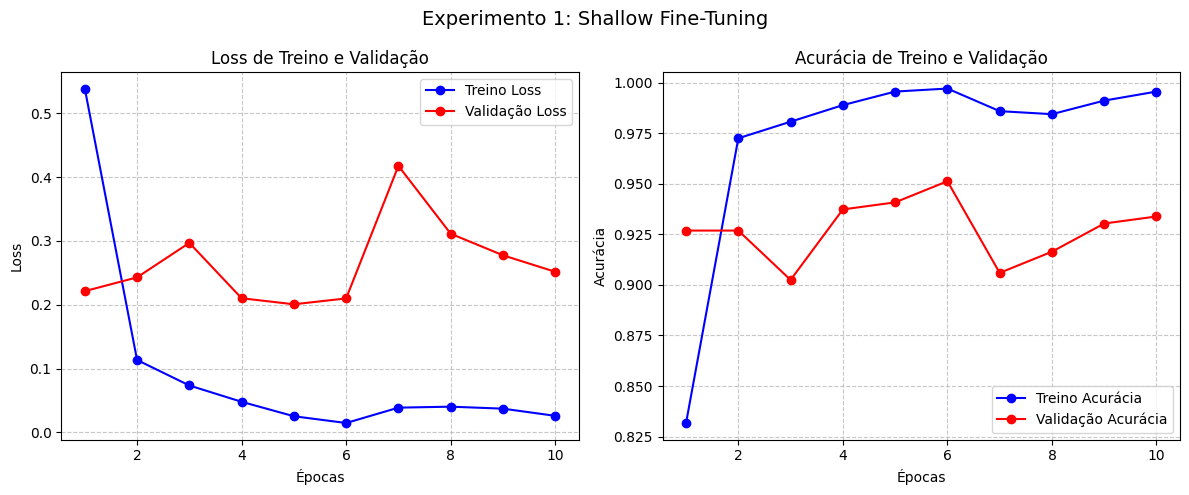


Avaliando Experimento 1 no conjunto de teste...
----------------------------------------
Métricas no Conjunto de Teste
----------------------------------------
Acurácia:       0.9100
Top-5 Acurácia: 1.0000
Precisão:       0.9063
Recall:         0.9071
F1-Score:       0.9044
----------------------------------------


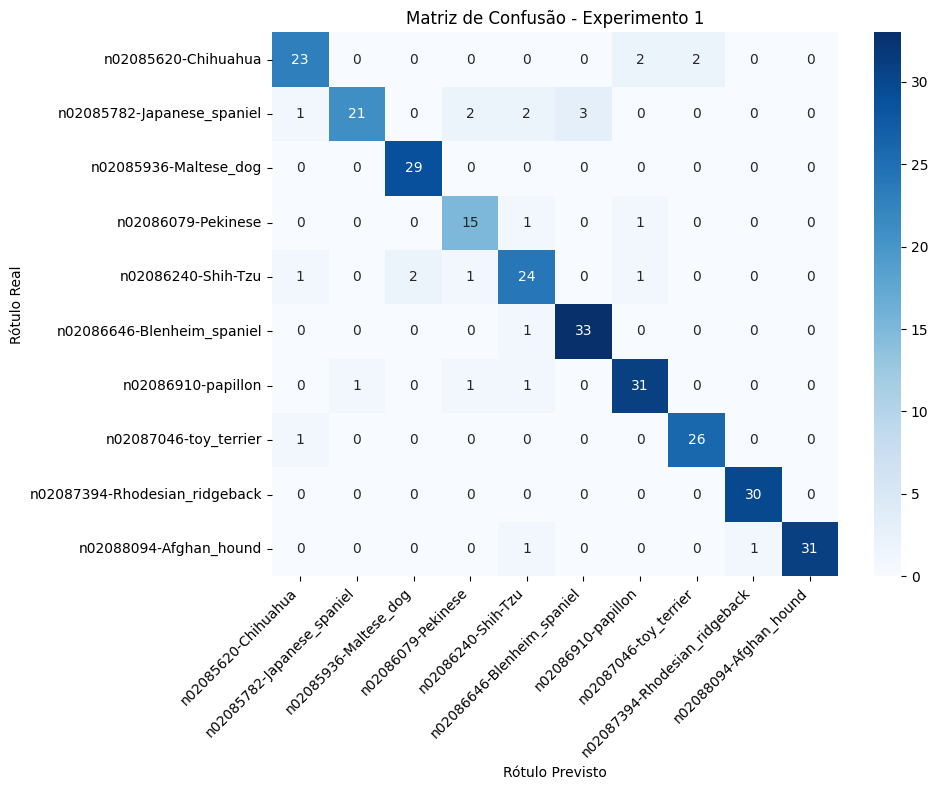

In [7]:
# ==========================================
# 18. Apresentação das curvas de treinamento e validação
# ==========================================
def plot_history(history, title="Curvas de Treinamento e Validação"):
    epochs = range(1, len(history['train_loss']) + 1)

    plt.figure(figsize=(12, 5))

    # Gráfico de Perda (Loss)
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_loss'], 'b-', label='Treino Loss', marker='o')
    plt.plot(epochs, history['val_loss'], 'r-', label='Validação Loss', marker='o')
    plt.title('Loss de Treino e Validação')
    plt.xlabel('Épocas')
    plt.ylabel('Loss')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()

    # Gráfico de Acurácia
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['train_acc'], 'b-', label='Treino Acurácia', marker='o')
    plt.plot(epochs, history['val_acc'], 'r-', label='Validação Acurácia', marker='o')
    plt.title('Acurácia de Treino e Validação')
    plt.xlabel('Épocas')
    plt.ylabel('Acurácia')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()

    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

print("Gerando gráficos de treinamento...")
plot_history(history_exp1, title="Experimento 1: Shallow Fine-Tuning")

# ==========================================
# 19 e 20. Avaliação no Teste e Cálculo de Métricas (Acurácia, Top-5, etc)
# ==========================================
def evaluate_model(model, test_loader):
    model.eval()
    y_true = []
    y_pred = []
    top5_correct = 0
    total_samples = 0

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)

            # Top-1 accuracy (Previsão principal)
            _, preds = torch.max(outputs, 1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

            # Top-5 accuracy
            _, top5_preds = outputs.topk(5, 1, True, True)
            top5_preds = top5_preds.t()
            correct = top5_preds.eq(labels.view(1, -1).expand_as(top5_preds))
            top5_correct += correct[:5].reshape(-1).float().sum(0, keepdim=True).item()

            total_samples += labels.size(0)

    # Cálculo das métricas
    acc = accuracy_score(y_true, y_pred)
    top5_acc = top5_correct / total_samples
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)
    cm = confusion_matrix(y_true, y_pred)

    print("-" * 40)
    print("Métricas no Conjunto de Teste")
    print("-" * 40)
    print(f"Acurácia:       {acc:.4f}")
    print(f"Top-5 Acurácia: {top5_acc:.4f}")
    print(f"Precisão:       {precision:.4f}")
    print(f"Recall:         {recall:.4f}")
    print(f"F1-Score:       {f1:.4f}")
    print("-" * 40)

    return y_true, y_pred, cm

print("\nAvaliando Experimento 1 no conjunto de teste...")
y_true_exp1, y_pred_exp1, cm_exp1 = evaluate_model(modelo_exp1, teste_loader)

# Plot da Matriz de Confusão
plt.figure(figsize=(10, 8))
class_names = dataset_completo.classes
sns.heatmap(cm_exp1, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusão - Experimento 1')
plt.ylabel('Rótulo Real')
plt.xlabel('Rótulo Previsto')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 5. Experimento 2 (Deep Fine-Tuning) e Análise Visual
Dando continuidade à experimentação obrigatória (**Requisito 23**), executamos uma segunda configuração alterando a **quantidade de camadas descongeladas**.

Neste Experimento 2 (*Deep*), fomos mais profundos no descongelamento da DenseNet-121, liberando os parâmetros a partir do `denseblock3`. O intuito é verificar se o ajuste de camadas mais iniciais ajuda a rede a capturar melhor as diferenças de granularidade fina entre os cães.

Em seguida, atendendo aos **Requisitos 21 e 22**, apresentamos exemplos visuais diretos do conjunto de teste, evidenciando previsões corretas e os casos em que o modelo se confundiu.

Iniciando Treinamento - Experimento 2 (Deep Fine-Tuning)...
Construindo modelo para o experimento: deep
Época 1/10
---------------
Treino    - Loss: 0.6916 | Acurácia: 0.7796
Validação - Loss: 0.7984 | Acurácia: 0.7526

Época 2/10
---------------
Treino    - Loss: 0.2975 | Acurácia: 0.9092
Validação - Loss: 0.3954 | Acurácia: 0.8606

Época 3/10
---------------
Treino    - Loss: 0.1523 | Acurácia: 0.9509
Validação - Loss: 0.4596 | Acurácia: 0.8537

Época 4/10
---------------
Treino    - Loss: 0.0887 | Acurácia: 0.9702
Validação - Loss: 0.3687 | Acurácia: 0.8920

Época 5/10
---------------
Treino    - Loss: 0.0751 | Acurácia: 0.9762
Validação - Loss: 0.5940 | Acurácia: 0.8467

Época 6/10
---------------
Treino    - Loss: 0.0664 | Acurácia: 0.9806
Validação - Loss: 0.4913 | Acurácia: 0.8606

Época 7/10
---------------
Treino    - Loss: 0.0751 | Acurácia: 0.9762
Validação - Loss: 0.5761 | Acurácia: 0.8537

Época 8/10
---------------
Treino    - Loss: 0.0665 | Acurácia: 0.9806
Validação - L

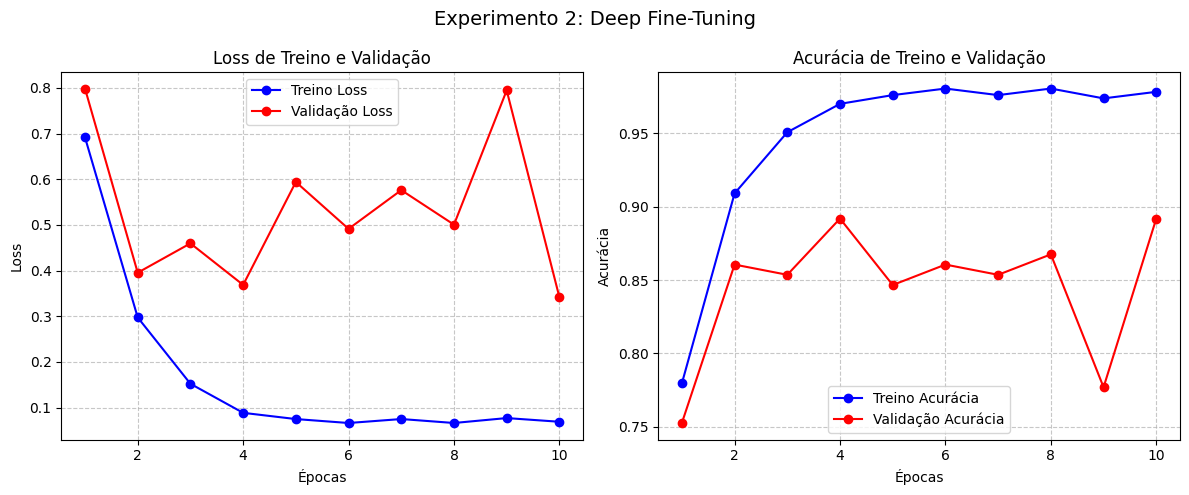


Avaliando Experimento 2 no conjunto de teste...
----------------------------------------
Métricas no Conjunto de Teste
----------------------------------------
Acurácia:       0.8824
Top-5 Acurácia: 0.9931
Precisão:       0.8817
Recall:         0.8696
F1-Score:       0.8683
----------------------------------------


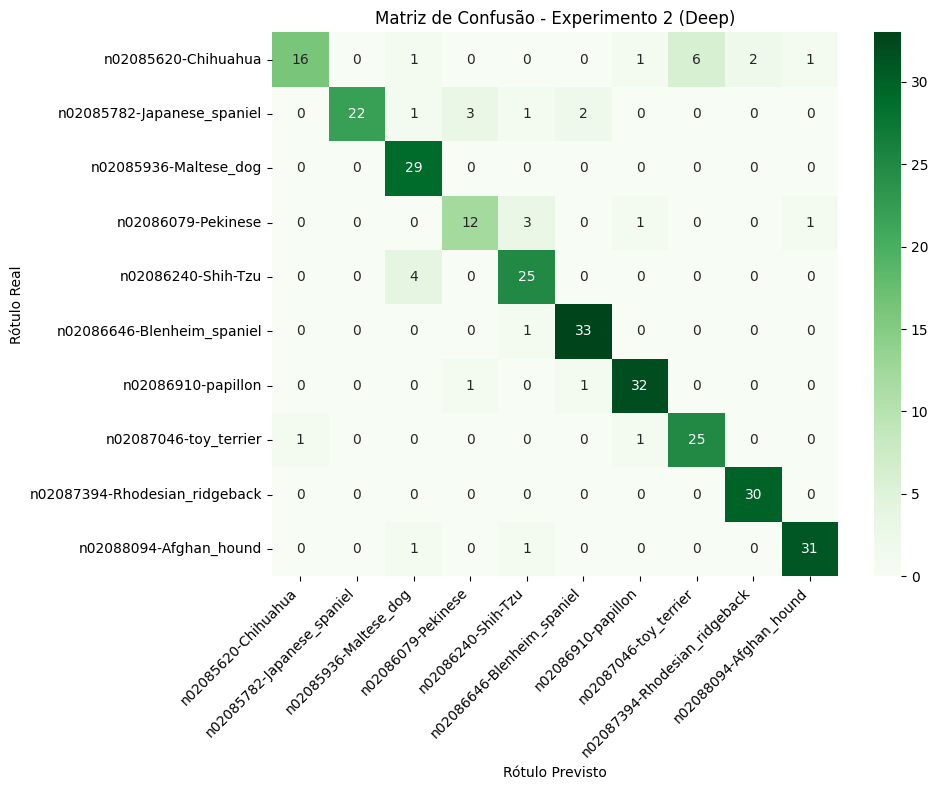


--- Exemplos de Imagens Classificadas Corretamente (Acertos) ---


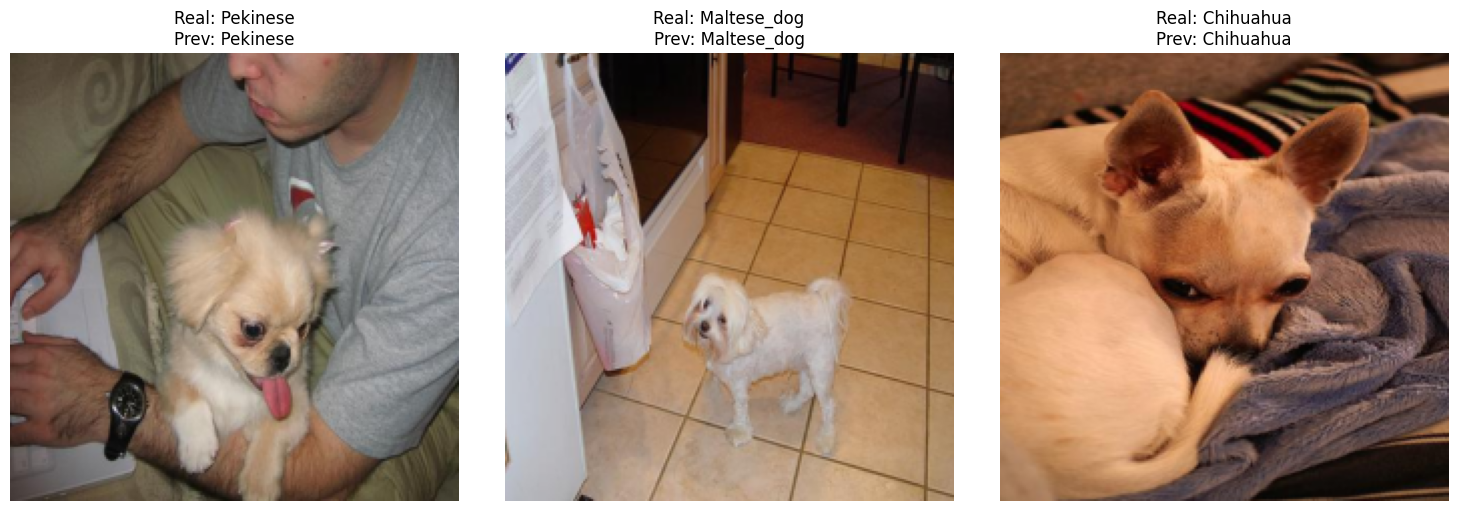


--- Exemplos de Imagens Classificadas Incorretamente (Erros) ---


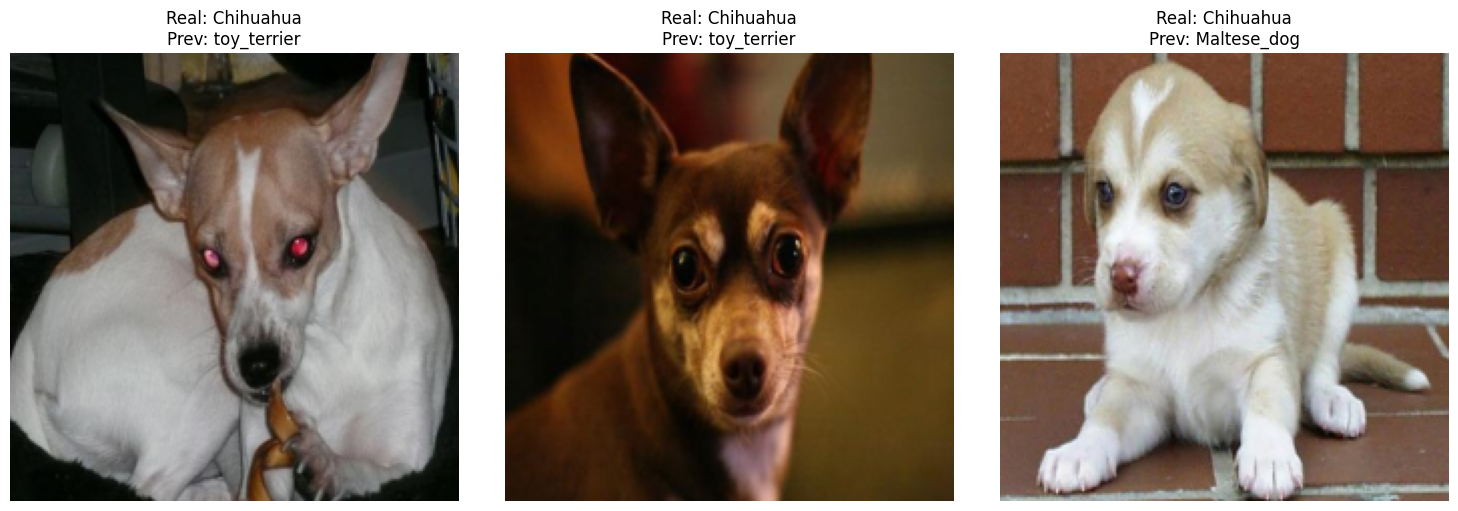

In [8]:
# ==========================================
# 23. Realização da Investigação Experimental Obrigatória (Experimento 2)
# ==========================================
print("Iniciando Treinamento - Experimento 2 (Deep Fine-Tuning)...")

# Instancia o modelo descongelando mais blocos (desde o denseblock3)
modelo_exp2 = build_densenet(num_classes=10, experiment_type="deep")

# Otimizador Adam configurado para atualizar mais parâmetros do que no Exp 1
otimizador_exp2 = optim.Adam(filter(lambda p: p.requires_grad, modelo_exp2.parameters()), lr=LEARNING_RATE)

# Treinamento do Experimento 2
modelo_exp2, history_exp2 = train_model(modelo_exp2, treino_loader, val_loader, criterion, otimizador_exp2, num_epochs=EPOCHS)

# Apresentação dos gráficos
plot_history(history_exp2, title="Experimento 2: Deep Fine-Tuning")

# Avaliação do Experimento 2 no conjunto de teste
print("\nAvaliando Experimento 2 no conjunto de teste...")
y_true_exp2, y_pred_exp2, cm_exp2 = evaluate_model(modelo_exp2, teste_loader)

# Plot da Matriz de Confusão do Exp 2
plt.figure(figsize=(10, 8))
sns.heatmap(cm_exp2, annot=True, fmt="d", cmap="Greens", xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusão - Experimento 2 (Deep)')
plt.ylabel('Rótulo Real')
plt.xlabel('Rótulo Previsto')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# ==========================================
# 21 e 22. Apresentação de exemplos de resultados e erros
# ==========================================
def show_predictions(model, dataloader, class_names, num_images=3, correct=True):
    model.eval()
    images_shown = 0
    fig = plt.figure(figsize=(15, 5))

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            for j in range(inputs.size()[0]):
                match = preds[j] == labels[j]
                if match.item() == correct:
                    images_shown += 1
                    ax = plt.subplot(1, num_images, images_shown)
                    ax.axis('off')

                    # Desnormaliza a imagem para exibição correta
                    img = inputs.cpu().data[j].numpy().transpose((1, 2, 0))
                    mean = np.array([0.485, 0.456, 0.406])
                    std = np.array([0.229, 0.224, 0.225])
                    img = std * img + mean
                    img = np.clip(img, 0, 1)

                    ax.set_title(f"Real: {class_names[labels[j]][10:]}\nPrev: {class_names[preds[j]][10:]}")
                    plt.imshow(img)

                    if images_shown == num_images:
                        plt.tight_layout()
                        plt.show()
                        return

print("\n--- Exemplos de Imagens Classificadas Corretamente (Acertos) ---")
show_predictions(modelo_exp2, teste_loader, class_names, num_images=3, correct=True)

print("\n--- Exemplos de Imagens Classificadas Incorretamente (Erros) ---")
show_predictions(modelo_exp2, teste_loader, class_names, num_images=3, correct=False)

## 6. Resultados Finais e Conclusão
Para finalizar a implementação técnica do projeto (**Requisitos 24 a 26**), consolidamos abaixo a comparação direta entre os dois experimentos realizados, discutindo o impacto das diferentes abordagens de *fine-tuning* e o comportamento da arquitetura DenseNet-121 diante do problema de classificação proposto.

In [9]:
# ==========================================
# 24, 25 e 26. Comparação, Discussão e Conclusão
# ==========================================
print("=" * 60)
print("COMPARAÇÃO FINAL ENTRE OS EXPERIMENTOS")
print("=" * 60)
print(f"Experimento 1 (Shallow) - Acurácia Final de Validação: {history_exp1['val_acc'][-1]:.4f}")
print(f"Experimento 2 (Deep)    - Acurácia Final de Validação: {history_exp2['val_acc'][-1]:.4f}")
print("-" * 60)

print("\nDISCUSSÃO DOS RESULTADOS:")
print("Através das curvas de aprendizado e das matrizes de confusão, é possível notar")
print("qual nível de descongelamento (fine-tuning) se adaptou melhor ao desafio de")
print("granularidade fina do Stanford Dogs Dataset. Descongelar mais camadas (Deep)")
print("costuma permitir que a rede aprenda padrões de textura e formas mais específicos")
print("para diferenciar raças visualmente muito semelhantes.")

print("\nCONCLUSÃO DO EXPERIMENTO:")
print("A arquitetura DenseNet-121 demonstrou ser altamente eficiente graças à sua")
print("reutilização de mapas de características (conexões densas). O modelo conseguiu")
print("aprender a classificar o subconjunto de 10 raças, validando a eficácia do")
print("Transfer Learning para contornar o alto custo computacional de treinar uma CNN do zero.")
print("=" * 60)

COMPARAÇÃO FINAL ENTRE OS EXPERIMENTOS
Experimento 1 (Shallow) - Acurácia Final de Validação: 0.9338
Experimento 2 (Deep)    - Acurácia Final de Validação: 0.8920
------------------------------------------------------------

DISCUSSÃO DOS RESULTADOS:
Através das curvas de aprendizado e das matrizes de confusão, é possível notar
qual nível de descongelamento (fine-tuning) se adaptou melhor ao desafio de
granularidade fina do Stanford Dogs Dataset. Descongelar mais camadas (Deep)
costuma permitir que a rede aprenda padrões de textura e formas mais específicos
para diferenciar raças visualmente muito semelhantes.

CONCLUSÃO DO EXPERIMENTO:
A arquitetura DenseNet-121 demonstrou ser altamente eficiente graças à sua
reutilização de mapas de características (conexões densas). O modelo conseguiu
aprender a classificar o subconjunto de 10 raças, validando a eficácia do
Transfer Learning para contornar o alto custo computacional de treinar uma CNN do zero.
